## MLFlow dependencies and initialization

In [1]:
import mlflow
from pprint import pprint

In [2]:
# Set here the URI from your MLFLow Tracking Server
TRACKING_URI = "http://localhost:5000"
client = mlflow.MlflowClient(tracking_uri=TRACKING_URI)
mlflow.set_tracking_uri(TRACKING_URI)

### Experiment creation

In [3]:
experiment_description = (
    "Training XGBoost for breast cancer detection. "
    "This approach uses MLFlow with hyperparameter tuning using Optuna."
)

experiment_tags = {
    "project_name": "breast-cancer-detection",
    "model_name": "xgboost",
    "mlflow.note.content": experiment_description,
    "parameters_tuner": "Optuna"
}

experiment_name = "XGB_Optuna_BreastCancerDetection_PNG"

exp = client.get_experiment_by_name(experiment_name)

if exp is None:
    exp_id = client.create_experiment(
        name=experiment_name, tags=experiment_tags
    )
else:
    exp_id = exp.experiment_id
    print(f"Experiment {experiment_name} already exists. Skipping creation")


Experiment XGB_Optuna_BreastCancerDetection_PNG already exists. Skipping creation


## Training Dependencies

In [4]:
from pathlib import Path
import sys

# Force add the project root to sys.path
project_root = Path("../").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from tqdm import tqdm
import optuna
from optuna.integration.mlflow import MLflowCallback

import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import os
import time
import uuid

# Import your custom modules
from training.engine import evaluate_ml
from inference.xgboost_explainer import XGBoostExplainer


C:\Users\Daniel\Documents\Personal\breast_cancer_detection\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [5]:
# Path to the dataset file
DATA_ABS_PATH        = os.path.abspath("D:/tfm/data")
IMAGES_ABS_PATH      = os.path.abspath("D:/tfm/data/CBIS-DDSM")
PNG_ABS_PATH         = os.path.abspath("D:/tfm/data/CBIS-DDSM-PNG")
CBISDDSM_FIXED_SET   = DATA_ABS_PATH + '/meta/CBIS-DDSM-fixed.parquet'
FEATURES_OUTPUT_PATH = os.path.abspath("../models/output/features/")

> Instructions in project's README about how to create these datasets below.

In [6]:
train_df = pq.read_table("train_png.parquet").to_pandas()
val_df = pq.read_table("val_png.parquet").to_pandas()
test_df = pq.read_table("test_png.parquet").to_pandas()

In [7]:
# ===== FEATURE EXTRACTION FUNCTIONS =====

def build_route(df, images_base_path=None):
    """
    Build the full image path for each row in the DataFrame and filter out non-existent files.
    
    Args:
        df (pd.DataFrame): Input dataframe with 'image_path' column containing relative paths.
        images_base_path (str): Base path for images. Defaults to PNG_ABS_PATH if None.
        
    Returns:
        pd.DataFrame: Filtered dataframe containing only rows with existing image files.
    """
    images_path = PNG_ABS_PATH if images_base_path is None else images_base_path

    df['full_image_path'] = df['image_path'].apply(
        lambda x: os.path.normpath(os.path.join(images_path, x))
    )
    df['exists'] = df['full_image_path'].apply(os.path.exists)
    
    missing_count = (~df['exists']).sum()
    if missing_count > 0:
        print(f"[WARN] {missing_count} images not found and will be filtered out")
    
    return df[df['exists']].copy()


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract basic image features from the input DataFrame.

    Args:
        df (pd.DataFrame): Input dataframe with 'full_image_path' column.

    Returns:
        pd.DataFrame: DataFrame with extracted image features merged.
    """
    import pydicom
    from PIL import Image
    
    features_list = []

    for path in tqdm(df["full_image_path"], desc="Extracting features"):
        try:
            if str(path).lower().endswith(".dcm"):
                # Read DICOM
                dicom = pydicom.dcmread(path)
                img_array = dicom.pixel_array.astype(np.float32)
            else:
                # Read PNG/JPEG
                img = Image.open(path).convert("L")
                img_array = np.asarray(img, dtype=np.float32)

            if img_array.size == 0:
                raise ValueError("Empty image.")

            # Normalize to [0, 1] using global scaling (safe for both DICOM and PNG)
            img_min = np.min(img_array)
            img_max = np.max(img_array)
            img_array = (img_array - img_min) / (img_max - img_min + 1e-8)

            mean_intensity = img_array.mean()
            std_intensity = img_array.std()
            height, width = img_array.shape

            features_list.append({
                "full_image_path": path,
                "mean_intensity": mean_intensity,
                "std_intensity": std_intensity,
                "width": width,
                "height": height
            })
        except Exception as e:
            print(f"[WARN] Error with image {path}: {e}")

    features_df = pd.DataFrame(features_list)
    merged_df = df.merge(features_df, on="full_image_path", how="inner")

    return merged_df


def load_or_extract_features(df, split: str, base_dir: str, images_base_path: str):
    """
    Load feature `.parquet` if it exists, otherwise compute and save it.
    
    Args:
        df (pd.DataFrame): The base dataframe with image paths.
        split (str): One of 'train', 'val', 'test'.
        base_dir (str): Directory where feature parquet files are stored.
        images_base_path (str): Base path for images.
        
    Returns:
        pd.DataFrame: DataFrame with extracted features.
    """
    feature_path = os.path.join(base_dir, f"{split}_features.parquet")
    
    if os.path.exists(feature_path):
        print(f"[INFO] Loading precomputed features for '{split}' from: {feature_path}")
        return pd.read_parquet(feature_path)
    
    print(f"[INFO] Extracting features for '{split}' (not cached)...")
    df = build_route(df, images_base_path=images_base_path)
    df = extract_features(df)
    df.to_parquet(feature_path, index=False)
    print(f"[INFO] Saved features to {feature_path}")
    
    return df

In [8]:
len(set(train_df["patient_id"]).intersection(val_df["patient_id"]))

0

In [9]:
assert set(train_df["patient_id"]).intersection(set(val_df["patient_id"])) == set()
assert set(train_df["patient_id"]).intersection(set(test_df["patient_id"])) == set()
assert set(val_df["patient_id"]).intersection(set(test_df["patient_id"])) == set()

In [10]:
# Run this to get the key info I need:

print("=== DATASET SIZE ===")
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

print("\n=== CLASS DISTRIBUTION ===")
print("Train:")
print(train_df["pathology"].value_counts())
print("\nVal:")
print(val_df["pathology"].value_counts())
print("\nTest:")
print(test_df["pathology"].value_counts())

print("\n=== UNIQUE PATIENTS ===")
print(f"Train patients: {train_df['patient_id'].nunique()}")
print(f"Val patients: {val_df['patient_id'].nunique()}")
print(f"Test patients: {test_df['patient_id'].nunique()}")

# Critical sanity check:
print("\n=== PATIENT LEAKAGE CHECK ===")
train_patients = set(train_df['patient_id'])
val_patients = set(val_df['patient_id'])
test_patients = set(test_df['patient_id'])
print(f"Train ∩ Val: {len(train_patients & val_patients)} (should be 0)")
print(f"Train ∩ Test: {len(train_patients & test_patients)} (should be 0)")
print(f"Val ∩ Test: {len(val_patients & test_patients)} (should be 0)")

=== DATASET SIZE ===
Train: 2315
Val: 559
Test: 694

=== CLASS DISTRIBUTION ===
Train:
pathology
MALIGNANT                  970
BENIGN                     882
BENIGN_WITHOUT_CALLBACK    463
Name: count, dtype: int64

Val:
pathology
BENIGN                     237
MALIGNANT                  223
BENIGN_WITHOUT_CALLBACK     99
Name: count, dtype: int64

Test:
pathology
BENIGN                     310
MALIGNANT                  264
BENIGN_WITHOUT_CALLBACK    120
Name: count, dtype: int64

=== UNIQUE PATIENTS ===
Train patients: 1001
Val patients: 251
Test patients: 314

=== PATIENT LEAKAGE CHECK ===
Train ∩ Val: 0 (should be 0)
Train ∩ Test: 0 (should be 0)
Val ∩ Test: 0 (should be 0)


### Set hyperparameters

In [11]:
# Correlation id for experiment tracking
correlation_id = uuid.uuid4()
corr_id = str(correlation_id)[:6]

### Set DataLoaders

In [12]:
# ===== FEATURE EXTRACTION =====
print("\n" + "="*60)
print("FEATURE EXTRACTION")
print("="*60)

# Extract or load features for all splits
train_df = load_or_extract_features(train_df, "train", FEATURES_OUTPUT_PATH, PNG_ABS_PATH)
val_df   = load_or_extract_features(val_df, "val", FEATURES_OUTPUT_PATH, PNG_ABS_PATH)
test_df  = load_or_extract_features(test_df, "test", FEATURES_OUTPUT_PATH, PNG_ABS_PATH)

print(f"\n[INFO] Train set: {len(train_df)} samples with features")
print(f"[INFO] Val set: {len(val_df)} samples with features")
print(f"[INFO] Test set: {len(test_df)} samples with features")

# Define feature columns
FEATURE_COLS = ['mean_intensity','std_intensity','width','height','assessment','breast_density','subtlety']

print(f"\n[INFO] Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")

# Extract X and y for each split
X_train = train_df[FEATURE_COLS].values
y_train = train_df['pathology'].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df['pathology'].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df['pathology'].values

# Optional: extract view info if available for per-view metrics
view_train = train_df['image_view'].values if 'image_view' in train_df.columns else None
view_val = val_df['image_view'].values if 'image_view' in val_df.columns else None
view_test = test_df['image_view'].values if 'image_view' in test_df.columns else None

print("\n[INFO] Feature extraction complete!")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  X_test shape: {X_test.shape}")

# MLFlow datasets (keep for tracking)
ml_train_dataset = mlflow.data.from_pandas(train_df, name="cbis_ddsm_train")
ml_val_dataset = mlflow.data.from_pandas(val_df, name="cbis_ddsm_val")
ml_test_dataset = mlflow.data.from_pandas(test_df, name="cbis_ddsm_test")


FEATURE EXTRACTION
[INFO] Loading precomputed features for 'train' from: C:\Users\Daniel\Documents\Personal\breast_cancer_detection\models\output\features\train_features.parquet
[INFO] Loading precomputed features for 'val' from: C:\Users\Daniel\Documents\Personal\breast_cancer_detection\models\output\features\val_features.parquet
[INFO] Loading precomputed features for 'test' from: C:\Users\Daniel\Documents\Personal\breast_cancer_detection\models\output\features\test_features.parquet

[INFO] Train set: 3381 samples with features
[INFO] Val set: 781 samples with features
[INFO] Test set: 918 samples with features

[INFO] Using 7 features: ['mean_intensity', 'std_intensity', 'width', 'height', 'assessment', 'breast_density', 'subtlety']

[INFO] Feature extraction complete!
  X_train shape: (3381, 7)
  X_val shape: (781, 7)
  X_test shape: (918, 7)


## Using my stuff for training

In [13]:
# ============================================================================
# SVM PREDICTOR CLASS FOR MLFLOW SERVING
# ============================================================================

import mlflow.pyfunc
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


class XGBoostImagePredictor(mlflow.pyfunc.PythonModel):
    """
    MLflow PyFunc flavor for SVM breast cancer classification.
    """
    
    def load_context(self, context):
        """
        Called once when model is loaded for serving.
        """
        import joblib
        
        # Load the SVM model and scaler from MLflow artifacts
        self.model = joblib.load(context.artifacts["model_path"])
        self.scaler = joblib.load(context.artifacts["scaler_path"])
        
        # Class names for interpretable output
        self.class_names = ['benign', 'benign_without_callback', 'malignant']
    
    def predict(self, context, model_input):
        """
        Accept feature vectors.
        
        Args:
            context: MLflow context
            model_input: pandas DataFrame with feature columns
        
        Returns:
            list of dicts with predictions
        """
        predictions = []
        
        # Scale features
        X_scaled = self.scaler.transform(model_input)
        
        # Get predictions and probabilities
        y_pred = self.model.predict(X_scaled)
        y_prob = self.model.predict_proba(X_scaled)
        
        for i in range(len(y_pred)):
            predicted_class = int(y_pred[i])
            predictions.append({
                'predicted_class': predicted_class,
                'predicted_class_name': self.class_names[predicted_class],
                'confidence': float(y_prob[i][predicted_class]),
                'probabilities': {
                    'benign': float(y_prob[i][0]),
                    'benign_without_callback': float(y_prob[i][1]),
                    'malignant': float(y_prob[i][2])
                }
            })
        
        return predictions

C:\Users\Daniel\Documents\Personal\breast_cancer_detection\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [14]:
import uuid
import optuna
import mlflow
import mlflow.xgboost
import joblib
import tempfile
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold

mlflow.set_experiment(experiment_name)

# Encode pathology labels for XGBoost
label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([y_train, y_val, y_test]))
y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

NUM_STUDIES = 2
N_TRIALS_PER_STUDY = 20

# Track the global best across ALL studies and trials
global_best_malignant_recall = 0.0
global_best_run_id = None
corr_id = str(correlation_id)[:6]

# Single registered model name for all versions
REGISTERED_MODEL_NAME = "xgboost-breast-cancer"

# Class names for reporting
class_names = label_encoder.classes_.tolist()

for study_number in range(NUM_STUDIES):
    study_name = f"xgb_study_{study_number}_{corr_id}"
    
    # Start a parent MLflow run for the study
    with mlflow.start_run(run_name=f"parent_{study_name}", nested=False) as parent_run:
        parent_run_id = parent_run.info.run_id
        
        mlflow.set_tag("study_name", study_name)
        mlflow.set_tag("correlation_id", corr_id)
        mlflow.log_param("study_number", study_number)

        study = optuna.create_study(
            study_name=study_name,
            direction="maximize",
            pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5),
            sampler=optuna.samplers.TPESampler(seed=42)
        )

        def objective(trial):
            global global_best_malignant_recall, global_best_run_id
        
            # Better hyperparameter space
            params = {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 8.0),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0.0, 3.0),  
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1e-1, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
            }
        
            with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True) as trial_run:
                trial_run_id = trial_run.info.run_id
        
                mlflow.log_params(params)
        
                # ===== PREPROCESSING OUTSIDE CV =====
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X_train)
        
                # ===== CROSS VALIDATION =====
                skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
                malignant_recalls = []
        
                for train_idx, val_idx in skf.split(X_scaled, y_train_enc):
                    X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
                    y_tr, y_va = y_train_enc[train_idx], y_train_enc[val_idx]
        
                    model = XGBClassifier(
                        objective="multi:softprob",
                        num_class=len(class_names),
                        tree_method="hist",
                        eval_metric="mlogloss",
                        random_state=42,
                        n_jobs=-1,
                        **params
                    )
        
                    model.fit(X_tr, y_tr)
        
                    # Predict
                    y_pred_prob = model.predict_proba(X_va)
                    y_pred = np.argmax(y_pred_prob, axis=1)
        
                    # Compute per-class metrics
                    metrics = classification_report(
                        y_va, y_pred, output_dict=True, zero_division=0
                    )
        
                    malignant_recall = metrics['2']['recall']  # class 2 is malignant
                    malignant_recalls.append(malignant_recall)
        
                # ===== CV SCORE =====
                cv_malignant_recall = np.mean(malignant_recalls)
                mlflow.log_metric("cv_malignant_recall", cv_malignant_recall)
        
                # ===== SAVE & REGISTER BEST =====
                if cv_malignant_recall > global_best_malignant_recall:
                    global_best_malignant_recall = cv_malignant_recall
                    global_best_run_id = trial_run_id
        
                    with tempfile.TemporaryDirectory() as tmpdir:
                        model_path = os.path.join(tmpdir, "model.pkl")
                        scaler_path = os.path.join(tmpdir, "scaler.pkl")
        
                        joblib.dump(model, model_path)
                        joblib.dump(scaler, scaler_path)
        
                        mlflow.xgboost.log_model(model, artifact_path="xgboost_model")
                        mlflow.log_artifact(scaler_path, artifact_path="artifacts")
        
                        mlflow.pyfunc.log_model(
                            artifact_path="xgb_predictor",
                            python_model=XGBoostImagePredictor(),
                            artifacts={
                                "model_path": model_path,
                                "scaler_path": scaler_path
                            },
                        )
        
                    mlflow.register_model(
                        f"runs:/{trial_run_id}/xgb_predictor",
                        name=REGISTERED_MODEL_NAME
                    )
        
                    mlflow.set_tag("is_best_model", True)
                else:
                    mlflow.set_tag("is_best_model", False)
        
                return cv_malignant_recall

        # Run the optimization
        study.optimize(objective, n_trials=N_TRIALS_PER_STUDY, show_progress_bar=True)

        # Log study summary
        mlflow.log_param("best_trial_number", study.best_trial.number)
        mlflow.log_param("best_malignant_recall", study.best_value)
        mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
        
        print(f"\nStudy {study_number} complete. Best malignant recall: {study.best_value:.4f}")

print(f"\n{'='*80}")
print(f"All studies completed.")
print(f"Global best malignant recall: {global_best_malignant_recall:.4f}")
print(f"Global best run ID: {global_best_run_id}")
print(f"Registered model: {REGISTERED_MODEL_NAME}")
print(f"{'='*80}")


[I 2025-11-15 19:14:48,628] A new study created in memory with name: xgb_study_0_6d2ac4


  0%|          | 0/20 [00:00<?, ?it/s]

2025/11/15 19:14:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\Daniel\Documents\Personal\breast_cancer_detection\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [19:14:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/11/15 19:14:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/15 19:14:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2025/11/15 19:14:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'xgboost-breast-cancer' already exists. Creating a new version of this model...
2025/11/15 19:14:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 8e2cb889babf4017a336f3f0168dfea8 has no artifacts at artifact path 'xgb_predictor', registering model based on models:/m-21cc6066a70c4afda81b30a935cdcc54 instead
2025/11/15 19:14:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost-breast-cancer, version 7
Created version '7' of model 'xgboost-breast-cancer'.


🏃 View run trial_0 at: http://localhost:5000/#/experiments/23/runs/8e2cb889babf4017a336f3f0168dfea8
🧪 View experiment at: http://localhost:5000/#/experiments/23
[I 2025-11-15 19:14:57,836] Trial 0 finished with value: 0.7437789661319073 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 10, 'min_child_weight': 6.123957592679836, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'reg_alpha': 2.5502648504032812e-08, 'reg_lambda': 2.9154431891537547, 'n_estimators': 561}. Best is trial 0 with value: 0.7437789661319073.
🏃 View run trial_1 at: http://localhost:5000/#/experiments/23/runs/e4ec12067c404e0f9bb11862d64c9322
🧪 View experiment at: http://localhost:5000/#/experiments/23
[I 2025-11-15 19:14:58,543] Trial 1 finished with value: 0.7179607843137256 and parameters: {'learning_rate': 0.11114989443094977, 'max_depth': 3, 'min_child_weight': 7.78936896513396, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356

...

2025/11/15 19:15:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'xgboost-breast-cancer' already exists. Creating a new version of this model...
2025/11/15 19:15:27 WARNING mlflow.tracking._model_registry.fluent: Run with id 80c942c3ebbd4b2eae794bc332c6901c has no artifacts at artifact path 'xgb_predictor', registering model based on models:/m-983832e50d994a089ec9d8c51372fa9f instead
2025/11/15 19:15:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost-breast-cancer, version 9
Created version '9' of model 'xgboost-breast-cancer'.


🏃 View run trial_14 at: http://localhost:5000/#/experiments/23/runs/80c942c3ebbd4b2eae794bc332c6901c
🧪 View experiment at: http://localhost:5000/#/experiments/23
[I 2025-11-15 19:15:28,122] Trial 14 finished with value: 0.7660059417706476 and parameters: {'learning_rate': 0.017283432495651358, 'max_depth': 8, 'min_child_weight': 2.6736828911573145, 'subsample': 0.8585163447841954, 'colsample_bytree': 0.7845148300030211, 'gamma': 0.07183443039085419, 'reg_alpha': 0.005930542151868122, 'reg_lambda': 0.32973231790647084, 'n_estimators': 659}. Best is trial 14 with value: 0.7660059417706476.
🏃 View run trial_15 at: http://localhost:5000/#/experiments/23/runs/e2edd8e37e004ec990832cbee9d34912
🧪 View experiment at: http://localhost:5000/#/experiments/23
[I 2025-11-15 19:15:29,449] Trial 15 finished with value: 0.7615662507427214 and parameters: {'learning_rate': 0.0169613604370429, 'max_depth': 8, 'min_child_weight': 3.0153650962554495, 'subsample': 0.8650068393934398, 'colsample_bytree': 0.8

[I 2025-11-15 19:15:34,521] A new study created in memory with name: xgb_study_1_6d2ac4


  0%|          | 0/20 [00:00<?, ?it/s]

🏃 View run trial_0 at: http://localhost:5000/#/experiments/23/runs/78aa33284ff442759575d67f470fdbb6
🧪 View experiment at: http://localhost:5000/#/experiments/23
[I 2025-11-15 19:15:35,613] Trial 0 finished with value: 0.7437789661319073 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 10, 'min_child_weight': 6.123957592679836, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'reg_alpha': 2.5502648504032812e-08, 'reg_lambda': 2.9154431891537547, 'n_estimators': 561}. Best is trial 0 with value: 0.7437789661319073.
🏃 View run trial_1 at: http://localhost:5000/#/experiments/23/runs/e5c07ea65aed45e3adec40f99b10899f
🧪 View experiment at: http://localhost:5000/#/experiments/23
[I 2025-11-15 19:15:36,329] Trial 1 finished with value: 0.7179607843137256 and parameters: {'learning_rate': 0.11114989443094977, 'max_depth': 3, 'min_child_weight': 7.78936896513396, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356

In [15]:
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import joblib

client = mlflow.tracking.MlflowClient()

# ===== LOAD BEST MODEL =====
print("" + "="*60)
print("LOADING BEST MODEL FOR TEST EVALUATION")
print("="*60)
print(f"Global best malignant recall: {global_best_malignant_recall:.4f}")
print(f"Global best run ID: {global_best_run_id}")

model_uri = f"runs:/{global_best_run_id}/xgboost_model"
model = mlflow.xgboost.load_model(model_uri)

scaler_path = client.download_artifacts(global_best_run_id, "artifacts/scaler.pkl")
scaler = joblib.load(scaler_path)

run = client.get_run(global_best_run_id)
best_params = run.data.params

print("Best hyperparameters used:")
for key in [
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "gamma",
    "reg_alpha",
    "reg_lambda",
    "n_estimators",
]:
    if key in best_params:
        print(f"  {key}: {best_params[key]}")

# ===== PREPARE TEST DATASET =====
print("" + "="*60)
print("PREPARING TEST DATASET")
print("="*60)

X_test_scaled = scaler.transform(X_test)

# ===== EVALUATE ON TEST SET =====
print("" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

test_acc, test_loss, test_recall, test_precision, test_f1, test_auc,     test_views, test_view_predictions, test_class_metrics = evaluate_ml(
        model,
        X_test_scaled,
        y_test_enc,
        view_info=None,
        class_names=class_names,
    )

test_malignant_recall = test_class_metrics.get("MALIGNANT", {}).get("recall", 0.0)

# ===== DISPLAY RESULTS =====
print("" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print("Overall Metrics:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"  AUC:       {test_auc:.4f}" if test_auc else "  AUC:       N/A")

print("CRITICAL METRIC:")
print(f"  Malignant (Class 2) Recall: {test_malignant_recall:.4f}")

print("Per-Class Metrics:")
for class_name, metrics in test_class_metrics.items():
    print(f"{class_name}:")
    for metric_name, value in metrics.items():
        display_value = value if value is not None else 0.0
        print(f"    {metric_name}: {display_value:.4f}")

# ===== LOG TEST RESULTS TO MLFLOW =====
print("" + "="*60)
print("LOGGING TEST RESULTS TO MLFLOW")
print("="*60)

mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name=f"test_evaluation_{corr_id}") as test_run:
    mlflow.set_tag("evaluation_type", "test_set")
    mlflow.set_tag("best_model_run_id", global_best_run_id)
    mlflow.set_tag("correlation_id", corr_id)

    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_f1", test_f1)
    if test_auc:
        mlflow.log_metric("test_auc", test_auc)
    mlflow.log_metric("test_malignant_recall", test_malignant_recall)

    for class_name, metrics in test_class_metrics.items():
        for metric_name, metric_value in metrics.items():
            value = metric_value if metric_value is not None else 0.0
            mlflow.log_metric(f"test_{class_name}_{metric_name}", value)

    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test_enc, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title("Confusion Matrix - Test Set", fontsize=14, fontweight="bold")
    plt.tight_layout()
    cm_path = f"test_confusion_matrix_{corr_id}.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    mlflow.log_artifact(cm_path)
    plt.close()

    comparison_data = {
        "Metric": ["Accuracy", "Recall", "Precision", "F1", "Malignant Recall"],
        "Validation": [
            float(run.data.metrics.get("val_accuracy", 0)),
            float(run.data.metrics.get("val_recall", 0)),
            float(run.data.metrics.get("val_precision", 0)),
            float(run.data.metrics.get("val_f1", 0)),
            float(run.data.metrics.get("val_malignant_recall", global_best_malignant_recall)),
        ],
        "Test": [test_acc, test_recall, test_precision, test_f1, test_malignant_recall],
    }

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(comparison_data["Metric"]))
    width = 0.35

    ax.bar(x - width / 2, comparison_data["Validation"], width, label="Validation", alpha=0.8)
    ax.bar(x + width / 2, comparison_data["Test"], width, label="Test", alpha=0.8)

    ax.set_xlabel("Metrics", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Performance: Validation vs Test", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_data["Metric"], rotation=45, ha="right")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    comparison_path = f"test_vs_validation_performance_{corr_id}.png"
    plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
    mlflow.log_artifact(comparison_path)
    plt.close()

    class_names_list = list(test_class_metrics.keys())
    recalls = [test_class_metrics[c].get("recall", 0) for c in class_names_list]
    precisions = [test_class_metrics[c].get("precision", 0) for c in class_names_list]
    f1_scores = [test_class_metrics[c].get("f1", 0) for c in class_names_list]

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(class_names_list))
    width = 0.25

    ax.bar(x - width, recalls, width, label="Recall", alpha=0.8)
    ax.bar(x, precisions, width, label="Precision", alpha=0.8)
    ax.bar(x + width, f1_scores, width, label="F1 Score", alpha=0.8)

    ax.set_xlabel("Class", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Per-Class Performance on Test Set", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(class_names_list, rotation=45, ha="right")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim([0, 1.1])
    plt.tight_layout()

    per_class_path = f"test_per_class_performance_{corr_id}.png"
    plt.savefig(per_class_path, dpi=300, bbox_inches="tight")
    mlflow.log_artifact(per_class_path)
    plt.close()

    print("Test results and visualizations logged to MLflow")

print("" + "="*60)
print("TEST EVALUATION COMPLETE")
print("="*60)
print(f"Final Test Malignant Recall: {test_malignant_recall:.4f}")
print(f"Registered Model: {REGISTERED_MODEL_NAME}")
print("="*60)


LOADING BEST MODEL FOR TEST EVALUATION
Global best malignant recall: 0.7660
Global best run ID: 80c942c3ebbd4b2eae794bc332c6901c


Best hyperparameters used:
  learning_rate: 0.017283432495651358
  max_depth: 8
  min_child_weight: 2.6736828911573145
  subsample: 0.8585163447841954
  colsample_bytree: 0.7845148300030211
  gamma: 0.07183443039085419
  reg_alpha: 0.005930542151868122
  reg_lambda: 0.32973231790647084
  n_estimators: 659
PREPARING TEST DATASET
EVALUATING ON TEST SET
TEST SET RESULTS
Overall Metrics:
  Accuracy:  0.7288
  Recall:    0.7420
  Precision: 0.7336
  F1 Score:  0.7358
  AUC:       0.9009
CRITICAL METRIC:
  Malignant (Class 2) Recall: 0.7304
Per-Class Metrics:
BENIGN:
    recall: 0.5869
    precision: 0.6776
    f1: 0.6290
    accuracy: 0.7353
    auc_roc: 0.8387
BENIGN_WITHOUT_CALLBACK:
    recall: 0.9088
    precision: 0.8706
    f1: 0.8893
    accuracy: 0.9325
    auc_roc: 0.9806
MALIGNANT:
    recall: 0.7304
    precision: 0.6524
    f1: 0.6892
    accuracy: 0.7898
    auc_roc: 0.8835
LOGGING TEST RESULTS TO MLFLOW
Test results and visualizations logged to MLflow
🏃 View run test_evaluatio

In [16]:
FEATURE_COLS

['mean_intensity',
 'std_intensity',
 'width',
 'height',
 'assessment',
 'breast_density',
 'subtlety']

GENERATING SHAP EXPLANATIONS

SHAP Summary Plot para: BENIGN


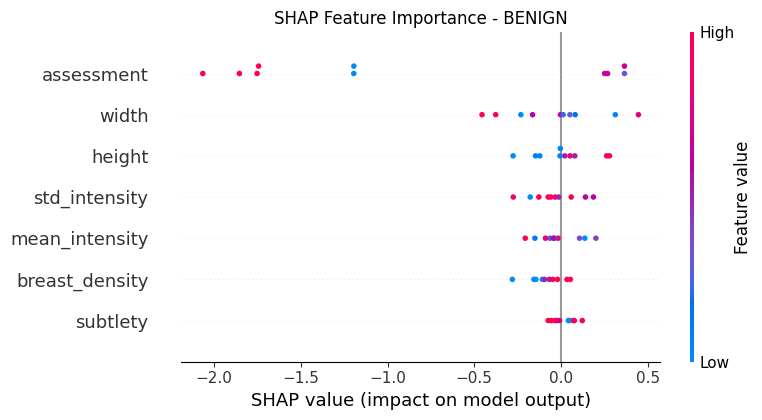


SHAP Summary Plot para: BENIGN_WITHOUT_CALLBACK


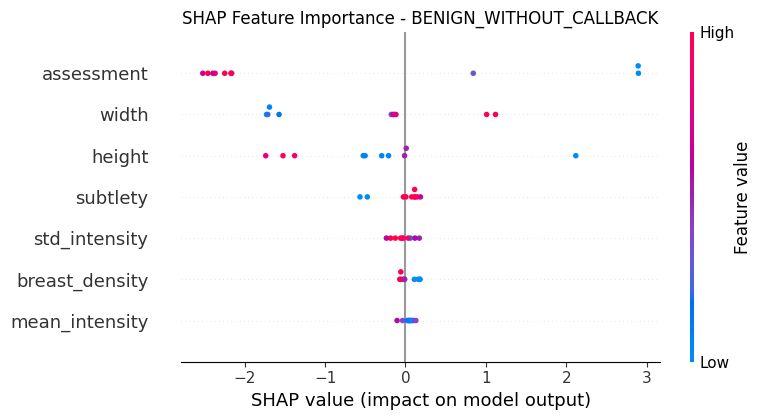


SHAP Summary Plot para: MALIGNANT


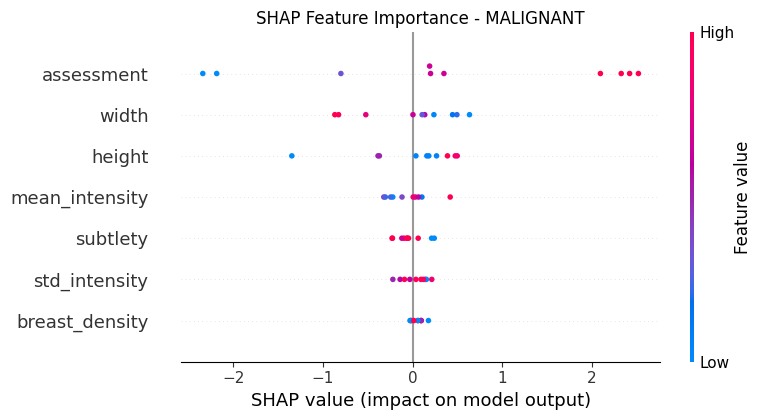

SHAP explanations generated and plotted


In [17]:
# ===== SHAP EXPLAINABILITY =====
print("" + "="*60)
print("GENERATING SHAP EXPLANATIONS")
print("="*60)

# Create explainer
explainer = XGBoostExplainer(
    model=model,
    scaler=scaler,
    feature_cols=FEATURE_COLS,
    label_list=class_names
)

X_sample = pd.DataFrame(X_test[:10])

# Generate SHAP explanations
shap_values = explainer.explain(X_sample)

print("SHAP explanations generated and plotted")
print("="*60)



FEATURE STATISTICS


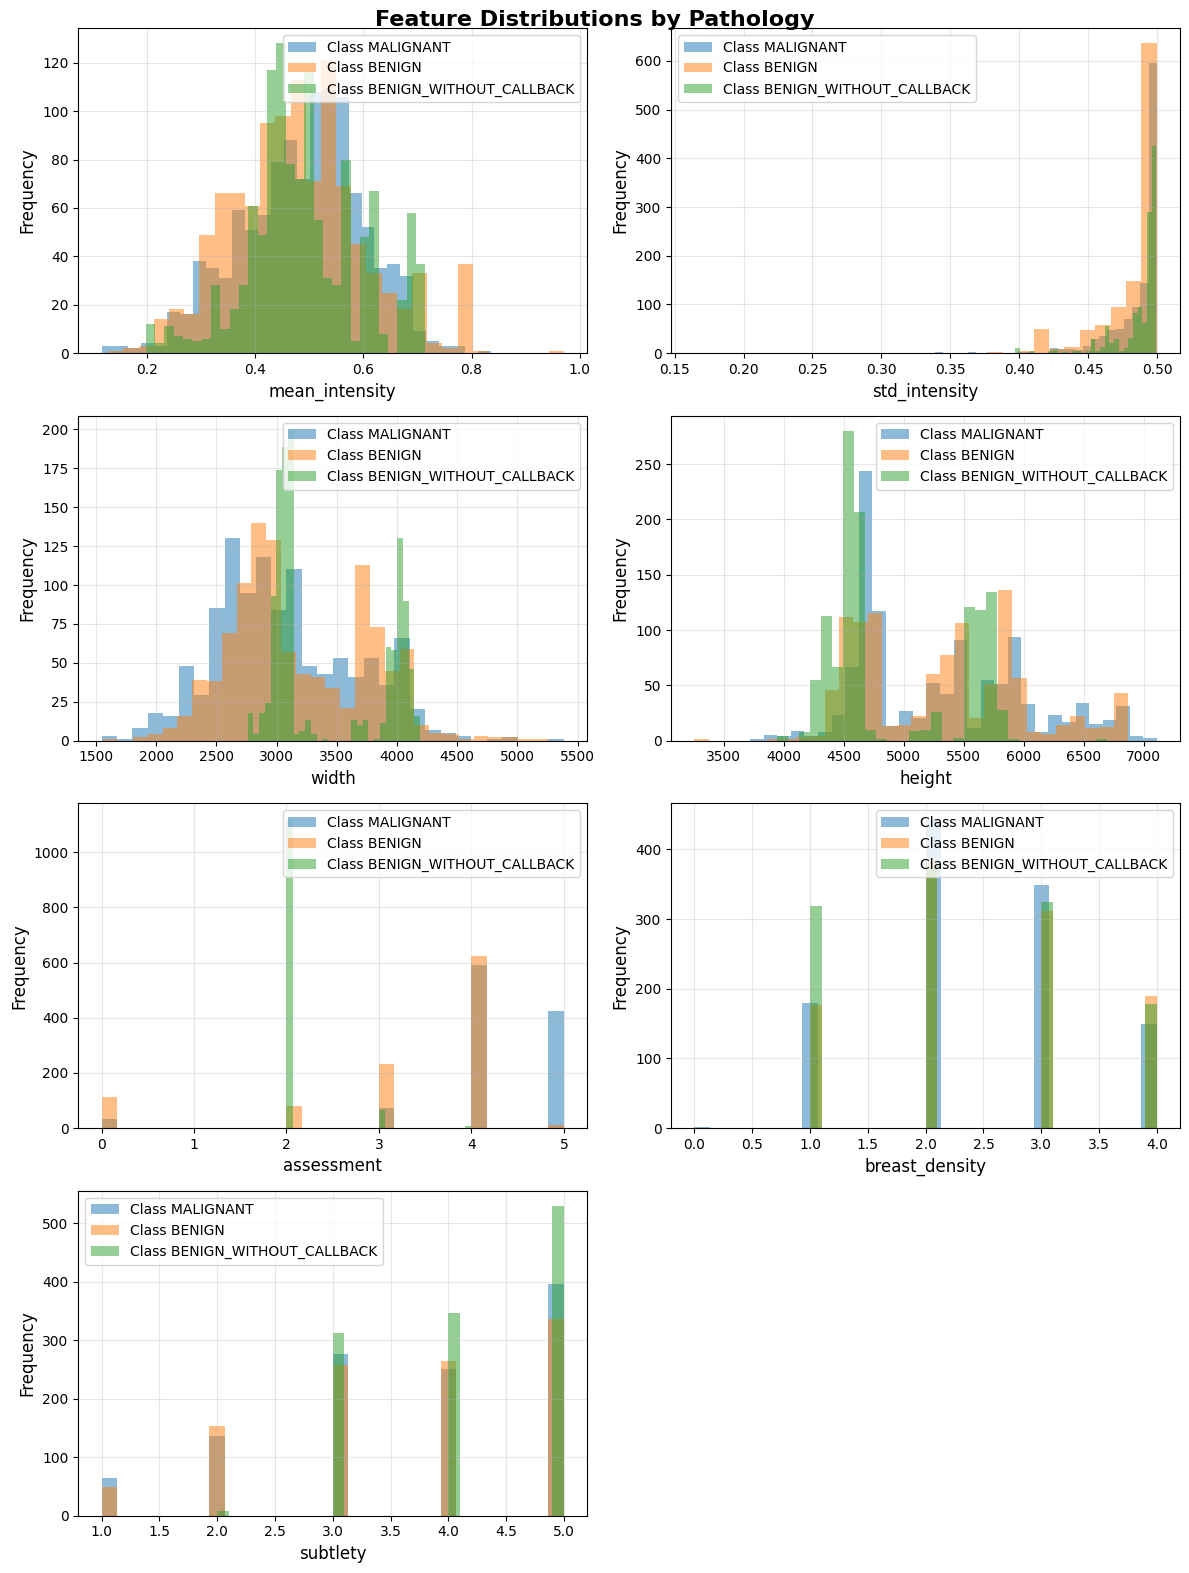


[INFO] Feature statistics:
       mean_intensity  std_intensity        width       height   assessment  \
count     3381.000000    3381.000000  3381.000000  3381.000000  3381.000000   
mean         0.487652       0.485392  3223.479148  5181.102928     3.132505   
std          0.114607       0.021142   558.491391   673.312898     1.266155   
min          0.116570       0.164411  1546.000000  3256.000000     0.000000   
25%          0.417374       0.482063  2872.000000  4600.000000     2.000000   
50%          0.487295       0.494227  3088.000000  5101.000000     3.000000   
75%          0.562378       0.498107  3744.000000  5704.000000     4.000000   
max          0.970453       0.499855  5386.000000  7111.000000     5.000000   

       breast_density     subtlety  
count     3381.000000  3381.000000  
mean         2.396037     3.845312  
std          0.974028     1.120030  
min          0.000000     1.000000  
25%          2.000000     3.000000  
50%          2.000000     4.000000  
7

In [19]:
# ===== FEATURE STATISTICS =====
print("\n" + "="*60)
print("FEATURE STATISTICS")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import math

num_features = len(FEATURE_COLS)

cols = 2
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

fig.suptitle('Feature Distributions by Pathology', fontsize=16, fontweight='bold')

for idx, feature in enumerate(FEATURE_COLS):
    ax = axes[idx]
    
    for pathology in train_df['pathology'].unique():
        subset = train_df[train_df['pathology'] == pathology][feature]
        ax.hist(subset, alpha=0.5, label=f'Class {pathology}', bins=30)
    
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

for ax in axes[num_features:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"feature_distributions_{corr_id}.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n[INFO] Feature statistics:")
print(train_df[FEATURE_COLS].describe())